Scenarios: 20 wind x 20 price x 4 SI = 1600 total
Scenario probability: pi = 0.000625

Building Gurobi model...
Set parameter OutputFlag to value 1
Model: 0 variables | 0 constraints
Solving...
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-7200U CPU @ 2.50GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 2 physical cores, 4 logical processors, using up to 4 threads

Optimize a model with 38400 rows, 76824 columns and 115200 nonzeros
Model fingerprint: 0xbd70af5a
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e-06, 1e+02]
  Bounds range     [5e+02, 5e+02]
  RHS range        [1e-01, 5e+02]
Presolve removed 38400 rows and 76824 columns
Presolve time: 0.12s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    3.3312946e+05   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.16 seconds (0.05 work units)
Optimal ob

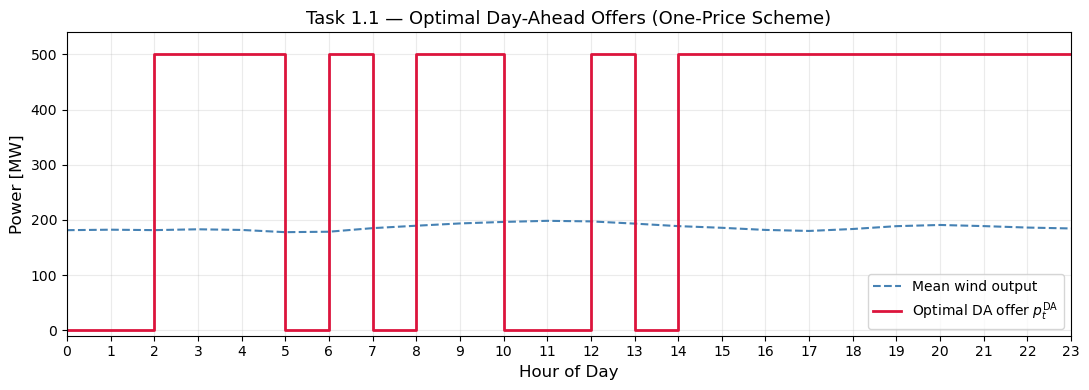

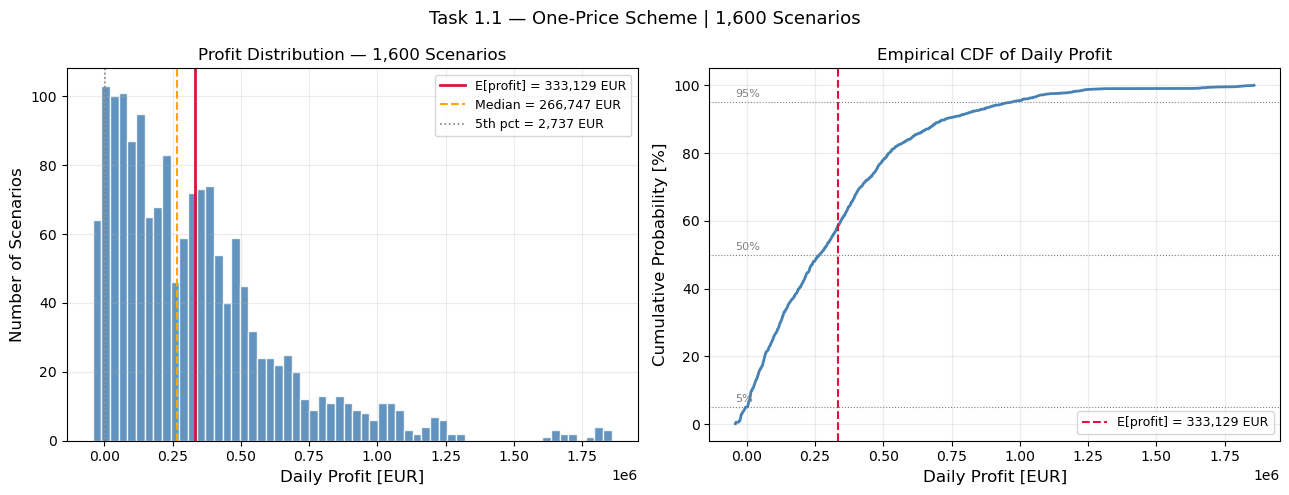

In [9]:
"""
Task 1.1 — Optimal Offering Strategy Under a One-Price Balancing Scheme
========================================================================
Stochastic LP formulation following Lecture 8. Solver: Gurobi.

Combined scenarios: 20 wind x 20 price x 4 SI = 1,600  (pi_w = 1/1600)

Objective:
  max  sum_t sum_w  pi_w * [ lambda_tw^DA * p_t^DA
                              + BP_tw * Delta_tw_up
                              - BP_tw * Delta_tw_down ]

  BP_tw = 1.25 * lambda_tw^DA  if SI_w(t) = 1  (system deficit)
        = 0.85 * lambda_tw^DA  if SI_w(t) = 0  (system surplus)

Variables:
  p_t^DA       -- first-stage DA offer [MW], NOT scenario-indexed
  Delta_tw_up  -- power excess  (wind > DA offer) [MW], second-stage
  Delta_tw_down-- power deficit (wind < DA offer) [MW], second-stage

Constraints:
  0 <= p_t^DA <= P_nom
  Delta_tw_up - Delta_tw_down = p_tw^wind - p_t^DA    for all t, w
  Delta_tw_up >= 0,  Delta_tw_down >= 0               for all t, w
"""

import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import itertools

# =============================================================================
# Configuration
# =============================================================================
WIND_CSV    = 'wind_scenarios_DK2.csv'
PRICE_CSV   = 'price_scenarios_DK2.csv'
SI_CSV      = 'si_scenarios.csv'

P_NOM       = 500.0   # MW installed capacity
BP_DEFICIT  = 1.25    # BP multiplier when SI = 1 (system deficit)
BP_SURPLUS  = 0.85    # BP multiplier when SI = 0 (system surplus)

# =============================================================================
# Load scenario data
# =============================================================================
wind_df  = pd.read_csv(WIND_CSV,  index_col='hour')      # (24, 20)
price_df = pd.read_csv(PRICE_CSV, index_col='hour')      # (24, 20)
si_df    = pd.read_csv(SI_CSV,    index_col='scenario')  # (4,  24)

T       = 24
N_WIND  = wind_df.shape[1]           # 20
N_PRICE = price_df.shape[1]          # 20
N_SI    = si_df.shape[0]             # 4
N_SCEN  = N_WIND * N_PRICE * N_SI   # 1600
PI      = 1.0 / N_SCEN

print(f"Scenarios: {N_WIND} wind x {N_PRICE} price x {N_SI} SI = {N_SCEN} total")
print(f"Scenario probability: pi = {PI:.6f}")

# =============================================================================
# Build combined scenario matrices  shape: (T=24, N_SCEN=1600)
# omega = (wind_i, price_j, si_k) -- full Cartesian product
# =============================================================================
combos = list(itertools.product(range(N_WIND), range(N_PRICE), range(N_SI)))

wind_mat  = np.zeros((T, N_SCEN))
price_mat = np.zeros((T, N_SCEN))
bp_mat    = np.zeros((T, N_SCEN))

for omega, (wi, pi_i, si_k) in enumerate(combos):
    wind_mat[:, omega]  = wind_df.iloc[:, wi].values
    price_mat[:, omega] = price_df.iloc[:, pi_i].values
    si_path             = si_df.iloc[si_k].values          # (24,) binary
    bp_mat[:, omega]    = np.where(
        si_path == 1,
        price_mat[:, omega] * BP_DEFICIT,
        price_mat[:, omega] * BP_SURPLUS
    )

# =============================================================================
# Build and solve the stochastic LP with Gurobi
# =============================================================================
print("\nBuilding Gurobi model...")
m = gp.Model("task1_1_one_price")
m.setParam("OutputFlag", 1)

# First-stage: DA offer per hour (T,)
p_DA = m.addMVar(T, lb=0.0, ub=P_NOM, name="p_DA")

# Second-stage: excess and deficit (T, N_SCEN)
delta_up   = m.addMVar((T, N_SCEN), lb=0.0, name="delta_up")
delta_down = m.addMVar((T, N_SCEN), lb=0.0, name="delta_down")

# Objective coefficients
# DA term: for each hour t, coefficient on p_DA[t] = sum_w pi * lambda_tw
da_coeff = (PI * price_mat).sum(axis=1)  # (T,)

# Balancing term: pi * BP_tw for each (t, w)
bp_coeff = PI * bp_mat  # (T, N_SCEN)

m.setObjective(
    da_coeff @ p_DA
    + gp.quicksum(
        bp_coeff[t, w] * delta_up[t, w] - bp_coeff[t, w] * delta_down[t, w]
        for t in range(T) for w in range(N_SCEN)
    ),
    GRB.MAXIMIZE
)

# Imbalance constraints: Delta_up - Delta_down = wind - p_DA  for all t, w
for t in range(T):
    m.addConstr(
        delta_up[t, :] - delta_down[t, :] == wind_mat[t, :] - p_DA[t],
        name=f"imbalance_t{t}"
    )

print(f"Model: {m.NumVars:,} variables | {m.NumConstrs:,} constraints")
print("Solving...")
m.optimize()

if m.Status != GRB.OPTIMAL:
    raise RuntimeError(f"No optimal solution found. Gurobi status: {m.Status}")

# =============================================================================
# Extract results
# =============================================================================
p_DA_opt       = p_DA.X                                      # (24,)
delta_up_opt   = delta_up.X                                  # (24, 1600)
delta_down_opt = delta_down.X                                # (24, 1600)

# Per-scenario daily profit (EUR)
da_revenue      = (price_mat * p_DA_opt[:, None]).sum(axis=0)
bal_revenue     = (bp_mat * (delta_up_opt - delta_down_opt)).sum(axis=0)
scenario_profits = da_revenue + bal_revenue                  # (1600,)
expected_profit  = scenario_profits.mean()

print(f"\nObjective value:      {m.ObjVal:,.2f} EUR")
print(f"Verified exp. profit: {expected_profit:,.2f} EUR")

# =============================================================================
# Save CSVs
# =============================================================================
pd.DataFrame({
    'hour':         range(T),
    'p_DA_opt_MW':  p_DA_opt,
    'mean_wind_MW': wind_mat.mean(axis=1),
    'pct_capacity': p_DA_opt / P_NOM * 100,
}).to_csv('task1_1_DA_offers.csv', index=False)

pd.DataFrame({
    'scenario':    range(N_SCEN),
    'profit_EUR':  scenario_profits,
}).to_csv('task1_1_scenario_profits.csv', index=False)

# =============================================================================
# All-or-nothing analysis
# =============================================================================
p_deficit   = si_df.values.mean()
e_bp_mult   = p_deficit * BP_DEFICIT + (1 - p_deficit) * BP_SURPLUS
threshold_p = (1.0 - BP_SURPLUS) / (BP_DEFICIT - BP_SURPLUS)  # = 0.375
aon          = e_bp_mult > 1.0

# =============================================================================
# Console summary
# =============================================================================
print("\n" + "=" * 62)
print("  TASK 1.1 RESULTS -- ONE-PRICE SCHEME")
print("=" * 62)
print(f"\n  Expected profit      : {expected_profit:>13,.2f} EUR")
print(f"  Std deviation        : {scenario_profits.std():>13,.2f} EUR")
print(f"  Min profit           : {scenario_profits.min():>13,.2f} EUR")
print(f"  5th  percentile      : {np.percentile(scenario_profits,  5):>13,.2f} EUR")
print(f"  Median               : {np.median(scenario_profits):>13,.2f} EUR")
print(f"  95th percentile      : {np.percentile(scenario_profits, 95):>13,.2f} EUR")
print(f"  Max profit           : {scenario_profits.max():>13,.2f} EUR")

print(f"\n  -- All-or-nothing analysis --")
print(f"  Avg deficit prob p       : {p_deficit:.4f}")
print(f"  E[BP] multiplier         : {e_bp_mult:.4f}  (p*1.25 + (1-p)*0.85)")
print(f"  Threshold for AoN        : p > {threshold_p:.4f}")
print(f"  Conclusion               : {'AoN -- withhold all from DA' if aon else 'No AoN -- offer tracks mean wind'}")

print(f"\n  -- Optimal DA offers per hour --")
print(f"  {'Hour':<6} {'p_DA (MW)':>10}  {'Mean wind':>10}  {'% Cap':>7}")
print("  " + "-" * 40)
for t in range(T):
    mw   = wind_mat[t, :].mean()
    flag = "  <- ZERO (withheld)" if p_DA_opt[t] < 0.5 else \
           "  <- FULL 500 MW"     if p_DA_opt[t] > P_NOM - 0.5 else ""
    print(f"  {t:<6} {p_DA_opt[t]:>10.2f}  {mw:>10.2f}  {p_DA_opt[t]/P_NOM*100:>6.1f}%{flag}")
print("=" * 62)

# =============================================================================
# Plot 1 -- Optimal DA offers vs wind scenario range
# =============================================================================
hours = np.arange(T)

fig, ax = plt.subplots(figsize=(11, 4))
#ax.fill_between(hours, wind_mat.min(axis=1), wind_mat.max(axis=1),
#                alpha=0.12, color='steelblue', label='Wind range (min\u2013max)')
ax.plot(hours, wind_mat.mean(axis=1),
        color='steelblue', linewidth=1.5, linestyle='--', label='Mean wind output')
ax.step(hours, p_DA_opt, where='post', color='crimson', linewidth=2,
        label=r'Optimal DA offer $p_t^{\mathrm{DA}}$')
#ax.axhline(P_NOM, color='grey', linestyle=':', linewidth=1,
#           label=f'Installed capacity ({P_NOM:.0f} MW)')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Power [MW]', fontsize=12)
ax.set_title('Task 1.1 \u2014 Optimal Day-Ahead Offers (One-Price Scheme)', fontsize=13)
ax.set_xticks(hours)
ax.set_xlim(0, T - 1)
ax.set_ylim(-10, P_NOM + 40)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('task1_1_DA_offers.pdf', dpi=150)
print("\nSaved: task1_1_DA_offers.pdf")

# =============================================================================
# Plot 2 -- Profit distribution: histogram + CDF
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Histogram ---
ax1.hist(scenario_profits, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(expected_profit,
            color='crimson', linewidth=2,
            label=f'E[profit] = {expected_profit:,.0f} EUR')
ax1.axvline(np.median(scenario_profits),
            color='orange', linewidth=1.5, linestyle='--',
            label=f'Median = {np.median(scenario_profits):,.0f} EUR')
ax1.axvline(np.percentile(scenario_profits, 5),
            color='grey', linewidth=1.2, linestyle=':',
            label=f'5th pct = {np.percentile(scenario_profits, 5):,.0f} EUR')
ax1.set_xlabel('Daily Profit [EUR]', fontsize=12)
ax1.set_ylabel('Number of Scenarios', fontsize=12)
ax1.set_title('Profit Distribution \u2014 1,600 Scenarios', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25)

# --- Empirical CDF ---
sorted_profits = np.sort(scenario_profits)
cdf = np.arange(1, N_SCEN + 1) / N_SCEN * 100
ax2.plot(sorted_profits, cdf, color='steelblue', linewidth=2)
ax2.axvline(expected_profit,
            color='crimson', linewidth=1.5, linestyle='--',
            label=f'E[profit] = {expected_profit:,.0f} EUR')
for pct in [5, 50, 95]:
    ax2.axhline(pct, color='grey', linewidth=0.8, linestyle=':')
    ax2.text(sorted_profits.min() * 1.01, pct + 1.5, f'{pct}%', fontsize=8, color='grey')
ax2.set_xlabel('Daily Profit [EUR]', fontsize=12)
ax2.set_ylabel('Cumulative Probability [%]', fontsize=12)
ax2.set_title('Empirical CDF of Daily Profit', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25)

plt.suptitle('Task 1.1 \u2014 One-Price Scheme | 1,600 Scenarios', fontsize=13)
plt.tight_layout()
plt.savefig('task1_1_profit_distribution.pdf', dpi=150)
print("Saved: task1_1_profit_distribution.pdf")
plt.show()

In [ ]:
# =============================================================================
# Task 1.2 — Two-Price Balancing Scheme
# =============================================================================

# -----------------------------------------------------------------------------
# Build SI matrix (T x N_SCEN)
# -----------------------------------------------------------------------------
si_mat = np.zeros((T, N_SCEN))
for omega, (wi, pi_i, si_k) in enumerate(combos):
    si_mat[:, omega] = si_df.iloc[si_k].values  # 1 = deficit, 0 = surplus

# -----------------------------------------------------------------------------
# Two-price settlement prices
# -----------------------------------------------------------------------------
# Settlement depends on whether imbalance is beneficial or harmful


# -----------------------------------------------------------------------------
# Build model
# -----------------------------------------------------------------------------
m2 = gp.Model("task1_2_two_price")
m2.setParam("OutputFlag", 1)

# First-stage decision
p_DA2 = m2.addMVar(T, lb=0.0, ub=P_NOM, name="p_DA2")

# Second-stage variables
delta_up2   = m2.addMVar((T, N_SCEN), lb=0.0, name="delta_up2")
delta_down2 = m2.addMVar((T, N_SCEN), lb=0.0, name="delta_down2")

# -----------------------------------------------------------------------------
# Objective
# -----------------------------------------------------------------------------
da_coeff2 = (PI * price_mat).sum(axis=1)

m2.setObjective(
    da_coeff2 @ p_DA2
    + gp.quicksum(
        PI * (
            np.where(si_mat[t, w] == 1, bp_mat[t, w], price_mat[t, w]) * delta_up2[t, w]
          - np.where(si_mat[t, w] == 1, price_mat[t, w], bp_mat[t, w]) * delta_down2[t, w]
        )
        for t in range(T) for w in range(N_SCEN)
    ),
    GRB.MAXIMIZE
)

# -----------------------------------------------------------------------------
# Constraints
# -----------------------------------------------------------------------------
for t in range(T):
    for w in range(N_SCEN):

        # imbalance identity
        m2.addConstr(
            delta_up2[t, w] - delta_down2[t, w]
            == wind_mat[t, w] - p_DA2[t]
        )

        # enforce correct decomposition (THIS IS THE KEY FIX)
        m2.addConstr(delta_up2[t, w] <= wind_mat[t, w])
        m2.addConstr(delta_down2[t, w] <= P_NOM - wind_mat[t, w])

# -----------------------------------------------------------------------------
# Solve
# -----------------------------------------------------------------------------
print("\nSolving Two-Price model...")
m2.optimize()

if m2.Status != GRB.OPTIMAL:
    raise RuntimeError(f"Gurobi status: {m2.Status}")

# -----------------------------------------------------------------------------
# Extract results
# -----------------------------------------------------------------------------
p_DA2_opt       = p_DA2.X
delta_up2_opt   = delta_up2.X
delta_down2_opt = delta_down2.X

# -----------------------------------------------------------------------------
# Profit calculation
# -----------------------------------------------------------------------------
da_revenue2 = (price_mat * p_DA2_opt[:, None]).sum(axis=0)

bal_revenue2 = (
    np.where(si_mat == 1, bp_mat, price_mat) * delta_up2_opt
  - np.where(si_mat == 1, price_mat, bp_mat) * delta_down2_opt
).sum(axis=0)

scenario_profits2 = da_revenue2 + bal_revenue2
expected_profit2  = scenario_profits2.mean()

# -----------------------------------------------------------------------------
# Print results
# -----------------------------------------------------------------------------
print("=" * 62)
print("  TASK 1.2 RESULTS -- TWO-PRICE SCHEME")
print("=" * 62)

print(f"  Expected profit : {expected_profit2:>13,.2f} EUR")
print(f"  Std deviation   : {scenario_profits2.std():>13,.2f} EUR")
print(f"  Min profit      : {scenario_profits2.min():>13,.2f} EUR")
print(f"  5th percentile  : {np.percentile(scenario_profits2,  5):>13,.2f} EUR")
print(f"  Median          : {np.median(scenario_profits2):>13,.2f} EUR")
print(f"  95th percentile : {np.percentile(scenario_profits2, 95):>13,.2f} EUR")
print(f"  Max profit      : {scenario_profits2.max():>13,.2f} EUR")

print(f"\n  Delta E[profit] (2P - 1P): {expected_profit2 - expected_profit:+,.2f} EUR")

# -----------------------------------------------------------------------------
# Compare DA offers
# -----------------------------------------------------------------------------
print(f"\n  {'Hour':<6} {'1P offer':>10}  {'2P offer':>10}  {'Delta':>8}")
print("  " + "-" * 40)

for t in range(T):
    print(f"  {t:<6} {p_DA_opt[t]:>10.2f}  {p_DA2_opt[t]:>10.2f}  {p_DA2_opt[t]-p_DA_opt[t]:>+8.2f}")

print("=" * 62)


# =============================================================================
# Plot 1 -- DA offers comparison (One-price vs Two-price)
# =============================================================================
hours = np.arange(T)

fig, ax = plt.subplots(figsize=(11, 4))

# Mean wind
ax.plot(hours, wind_mat.mean(axis=1),
        color='steelblue', linewidth=1.5, linestyle='--',
        label='Mean wind output')

# One-price
ax.step(hours, p_DA_opt, where='post',
        color='crimson', linewidth=2,
        label=r'One-price $p_t^{\mathrm{DA}}$')

# Two-price
ax.step(hours, p_DA2_opt, where='post',
        color='darkgreen', linewidth=2, linestyle='--',
        label=r'Two-price $p_t^{\mathrm{DA}}$')

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Power [MW]', fontsize=12)
ax.set_title('DA Offers Comparison (One vs Two-Price Schemes)', fontsize=13)

ax.set_xticks(hours)
ax.set_xlim(0, T - 1)
ax.set_ylim(-10, max(P_NOM, p_DA_opt.max(), p_DA2_opt.max()) + 40)

ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('DA_offers_comparison.pdf', dpi=150)
print("\nSaved: DA_offers_comparison.pdf")

plt.show()


# =============================================================================
# Plot 2 -- Profit distribution comparison
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Histogram ---
ax1.hist(scenario_profits, bins=60,
         color='steelblue', edgecolor='white', alpha=0.75,
         label='One-price')

ax1.hist(scenario_profits2, bins=60,
         color='darkgreen', edgecolor='white', alpha=0.5,
         label='Two-price')

# Expected values
ax1.axvline(expected_profit,
            color='crimson', linewidth=2,
            label=f'One-price E = {expected_profit:,.0f} EUR')

ax1.axvline(expected_profit2,
            color='darkgreen', linewidth=2, linestyle='--',
            label=f'Two-price E = {expected_profit2:,.0f} EUR')

ax1.set_xlabel('Daily Profit [EUR]', fontsize=12)
ax1.set_ylabel('Number of Scenarios', fontsize=12)
ax1.set_title('Profit Distribution Comparison', fontsize=12)

ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25)


# --- Empirical CDF ---
sorted_p1 = np.sort(scenario_profits)
sorted_p2 = np.sort(scenario_profits2)
cdf = np.arange(1, N_SCEN + 1) / N_SCEN * 100

ax2.plot(sorted_p1, cdf,
         color='steelblue', linewidth=2,
         label='One-price')

ax2.plot(sorted_p2, cdf,
         color='darkgreen', linewidth=2, linestyle='--',
         label='Two-price')

# Expected value markers
ax2.axvline(expected_profit,
            color='crimson', linewidth=1.5, linestyle='--')

ax2.axvline(expected_profit2,
            color='darkgreen', linewidth=1.5, linestyle=':')

# Percentile reference lines
for pct in [5, 50, 95]:
    ax2.axhline(pct, color='grey', linewidth=0.8, linestyle=':')
    ax2.text(min(sorted_p1.min(), sorted_p2.min()) * 1.01,
             pct + 1.5, f'{pct}%', fontsize=8, color='grey')

ax2.set_xlabel('Daily Profit [EUR]', fontsize=12)
ax2.set_ylabel('Cumulative Probability [%]', fontsize=12)
ax2.set_title('Empirical CDF Comparison', fontsize=12)

ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25)


plt.suptitle('One-price vs Two-price Schemes | Profit Analysis', fontsize=13)

plt.tight_layout()
plt.savefig('profit_distribution_comparison.pdf', dpi=150)
print("Saved: profit_distribution_comparison.pdf")

plt.show()

Set parameter OutputFlag to value 1


NameError: name 'da_coeff2' is not defined

In [ ]:
# =============================================================================
# Task 1.2 — Two-Price Balancing Scheme
# =============================================================================

# -----------------------------------------------------------------------------
# Build SI matrix (T x N_SCEN)
# -----------------------------------------------------------------------------
si_mat = np.array([si_df.iloc[si_k].values for _, _, si_k in combos]).T

# -----------------------------------------------------------------------------
# Two-price settlement prices
# -----------------------------------------------------------------------------
# Settlement depends on whether imbalance is beneficial or harmful


# -----------------------------------------------------------------------------
# Build model
# -----------------------------------------------------------------------------
m2 = gp.Model("task1_2_two_price")
m2.setParam("OutputFlag", 1)

# First-stage decision
p_DA2 = m2.addMVar(T, lb=0.0, ub=P_NOM, name="p_DA2")

# Second-stage variables
delta_up2   = m2.addMVar((T, N_SCEN), lb=0.0, name="delta_up2")
delta_down2 = m2.addMVar((T, N_SCEN), lb=0.0, name="delta_down2")

da_coeff2 = (PI * price_mat).sum(axis=1)


# -----------------------------------------------------------------------------
# Objective
# -----------------------------------------------------------------------------
m2.setObjective(
    da_coeff2 @ p_DA2
    + gp.quicksum(
        PI * (
            np.where(si_mat[t, w] == 1, bp_mat[t, w], price_mat[t, w]) * delta_up2[t, w]
          - np.where(si_mat[t, w] == 1, price_mat[t, w], bp_mat[t, w]) * delta_down2[t, w]
        )
        for t in range(T) for w in range(N_SCEN)
    ),
    GRB.MAXIMIZE
)

# -----------------------------------------------------------------------------
# Constraints
# -----------------------------------------------------------------------------
for t in range(T):
    for w in range(N_SCEN):

        # imbalance identity
        m2.addConstr(
            delta_up2[t, w] - delta_down2[t, w]
            == wind_mat[t, w] - p_DA2[t]
        )

        # enforce correct decomposition (THIS IS THE KEY FIX)
        m2.addConstr(delta_up2[t, w] <= wind_mat[t, w])
        m2.addConstr(delta_down2[t, w] <= P_NOM - wind_mat[t, w])

# -----------------------------------------------------------------------------
# Solve
# -----------------------------------------------------------------------------
print("\nSolving Two-Price model...")
m2.optimize()

if m2.Status != GRB.OPTIMAL:
    raise RuntimeError(f"Gurobi status: {m2.Status}")

# -----------------------------------------------------------------------------
# Extract results
# -----------------------------------------------------------------------------
p_DA2_opt       = p_DA2.X
delta_up2_opt   = delta_up2.X
delta_down2_opt = delta_down2.X

# -----------------------------------------------------------------------------
# Profit calculation
# -----------------------------------------------------------------------------
da_revenue2 = (price_mat * p_DA2_opt[:, None]).sum(axis=0)

bal_revenue2 = (
    np.where(si_mat == 1, bp_mat, price_mat) * delta_up2_opt
  - np.where(si_mat == 1, price_mat, bp_mat) * delta_down2_opt
).sum(axis=0)

scenario_profits2 = da_revenue2 + bal_revenue2
expected_profit2  = scenario_profits2.mean()

# -----------------------------------------------------------------------------
# Print results
# -----------------------------------------------------------------------------
print("=" * 62)
print("  TASK 1.2 RESULTS -- TWO-PRICE SCHEME")
print("=" * 62)

print(f"  Expected profit : {expected_profit2:>13,.2f} EUR")
print(f"  Std deviation   : {scenario_profits2.std():>13,.2f} EUR")
print(f"  Min profit      : {scenario_profits2.min():>13,.2f} EUR")
print(f"  5th percentile  : {np.percentile(scenario_profits2,  5):>13,.2f} EUR")
print(f"  Median          : {np.median(scenario_profits2):>13,.2f} EUR")
print(f"  95th percentile : {np.percentile(scenario_profits2, 95):>13,.2f} EUR")
print(f"  Max profit      : {scenario_profits2.max():>13,.2f} EUR")

print(f"\n  Delta E[profit] (2P - 1P): {expected_profit2 - expected_profit:+,.2f} EUR")

# -----------------------------------------------------------------------------
# Compare DA offers
# -----------------------------------------------------------------------------
print(f"\n  {'Hour':<6} {'1P offer':>10}  {'2P offer':>10}  {'Delta':>8}")
print("  " + "-" * 40)

for t in range(T):
    print(f"  {t:<6} {p_DA_opt[t]:>10.2f}  {p_DA2_opt[t]:>10.2f}  {p_DA2_opt[t]-p_DA_opt[t]:>+8.2f}")

print("=" * 62)


# =============================================================================
# Plot 1 -- DA offers comparison (One-price vs Two-price)
# =============================================================================
hours = np.arange(T)

fig, ax = plt.subplots(figsize=(11, 4))

# Mean wind
ax.plot(hours, wind_mat.mean(axis=1),
        color='steelblue', linewidth=1.5, linestyle='--',
        label='Mean wind output')

# One-price
ax.step(hours, p_DA_opt, where='post',
        color='crimson', linewidth=2,
        label=r'One-price $p_t^{\mathrm{DA}}$')

# Two-price
ax.step(hours, p_DA2_opt, where='post',
        color='darkgreen', linewidth=2, linestyle='--',
        label=r'Two-price $p_t^{\mathrm{DA}}$')

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Power [MW]', fontsize=12)
ax.set_title('DA Offers Comparison (One vs Two-Price Schemes)', fontsize=13)

ax.set_xticks(hours)
ax.set_xlim(0, T - 1)
ax.set_ylim(-10, max(P_NOM, p_DA_opt.max(), p_DA2_opt.max()) + 40)

ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('DA_offers_comparison.pdf', dpi=150)
print("\nSaved: DA_offers_comparison.pdf")

plt.show()


# =============================================================================
# Plot 2 -- Profit distribution comparison
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Histogram ---
ax1.hist(scenario_profits, bins=60,
         color='steelblue', edgecolor='white', alpha=0.75,
         label='One-price')

ax1.hist(scenario_profits2, bins=60,
         color='darkgreen', edgecolor='white', alpha=0.5,
         label='Two-price')

# Expected values
ax1.axvline(expected_profit,
            color='crimson', linewidth=2,
            label=f'One-price E = {expected_profit:,.0f} EUR')

ax1.axvline(expected_profit2,
            color='darkgreen', linewidth=2, linestyle='--',
            label=f'Two-price E = {expected_profit2:,.0f} EUR')

ax1.set_xlabel('Daily Profit [EUR]', fontsize=12)
ax1.set_ylabel('Number of Scenarios', fontsize=12)
ax1.set_title('Profit Distribution Comparison', fontsize=12)

ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25)


# --- Empirical CDF ---
sorted_p1 = np.sort(scenario_profits)
sorted_p2 = np.sort(scenario_profits2)
cdf = np.arange(1, N_SCEN + 1) / N_SCEN * 100

ax2.plot(sorted_p1, cdf,
         color='steelblue', linewidth=2,
         label='One-price')

ax2.plot(sorted_p2, cdf,
         color='darkgreen', linewidth=2, linestyle='--',
         label='Two-price')

# Expected value markers
ax2.axvline(expected_profit,
            color='crimson', linewidth=1.5, linestyle='--')

ax2.axvline(expected_profit2,
            color='darkgreen', linewidth=1.5, linestyle=':')

# Percentile reference lines
for pct in [5, 50, 95]:
    ax2.axhline(pct, color='grey', linewidth=0.8, linestyle=':')
    ax2.text(min(sorted_p1.min(), sorted_p2.min()) * 1.01,
             pct + 1.5, f'{pct}%', fontsize=8, color='grey')

ax2.set_xlabel('Daily Profit [EUR]', fontsize=12)
ax2.set_ylabel('Cumulative Probability [%]', fontsize=12)
ax2.set_title('Empirical CDF Comparison', fontsize=12)

ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25)


plt.suptitle('One-price vs Two-price Schemes | Profit Analysis', fontsize=13)

plt.tight_layout()
plt.savefig('profit_distribution_comparison.pdf', dpi=150)
print("Saved: profit_distribution_comparison.pdf")

plt.show()

Set parameter OutputFlag to value 1


NameError: name 'da_coeff2' is not defined